# Maritime Trend Analysis Notebook
This notebook reproduces correlation, lag, and period analysis.

In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('Object detected - Sheet1.csv')

# Clean date
df['Date_clean'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date_clean')

# Select variables
df = df[['Date_clean',
         'Vessel detected in the open-water proximity to the port',
         'Brent_Oil_Price_USD',
         'Barcelona_Traffic_MTonnes',
         'tavg','wspd','pres']].dropna()

df.columns = ['date','vessel','oil','traffic','temp','wind','pressure']

df.head()

,date,vessel,oil,traffic,temp,wind,pressure
0,2020-12-31,3.0,50.0,4.8,10.6,17.8,1019.2
1,2021-01-13,3.0,55.0,5.0,10.7,14.3,1012.3
2,2021-07-24,8.0,62.0,5.2,8.5,14.8,1009.5
3,2021-09-11,3.0,65.0,5.4,9.4,12.5,994.0
4,2021-09-17,3.0,64.0,5.5,6.9,17.4,998.5


## Correlation Analysis

In [2]:
corr = df[['vessel','oil','traffic','temp','wind','pressure']].corr()
corr

,vessel,oil,traffic,temp,wind,pressure
vessel,1.000000,0.615931,0.382944,-0.184773,-0.007185,-0.012545
oil,0.615931,1.000000,0.927541,-0.161976,-0.283199,-0.540455
traffic,0.382944,0.927541,1.000000,-0.334933,-0.228824,-0.734170
temp,-0.184773,-0.161976,-0.334933,1.000000,-0.132758,0.532627
wind,-0.007185,-0.283199,-0.228824,-0.132758,1.000000,0.482101
pressure,-0.012545,-0.540455,-0.734170,0.532627,0.482101,1.000000


## Lag Analysis

In [3]:
lags = range(-3,4)
results = []

for lag in lags:
    corr = df['vessel'].corr(df['oil'].shift(lag))
    results.append((lag, corr))

lag_df = pd.DataFrame(results, columns=['lag','correlation'])
lag_df

,lag,correlation
0,-3,0.212741
1,-2,0.491257
2,-1,0.735376
3,0,0.615931
4,1,0.528834
5,2,0.256495
6,3,0.476623


## Period Segmentation

In [4]:
def classify(date):
    if date <= pd.Timestamp('2021-06-30'):
        return 'COVID'
    elif date <= pd.Timestamp('2022-01-31'):
        return 'Post-COVID'
    else:
        return 'War'

df['period'] = df['date'].apply(classify)

summary = df.groupby('period').mean()
summary

,date,vessel,oil,traffic,temp,wind,pressure
period,,,,,,,
COVID,2021-01-06 12:00:00,3.0,52.50,4.900,10.65,16.050,1015.750
Post-COVID,2021-09-04 06:00:00,5.5,64.75,5.400,8.40,15.125,1001.275
War,2022-03-28 12:00:00,8.5,73.25,5.525,9.80,15.225,1005.800


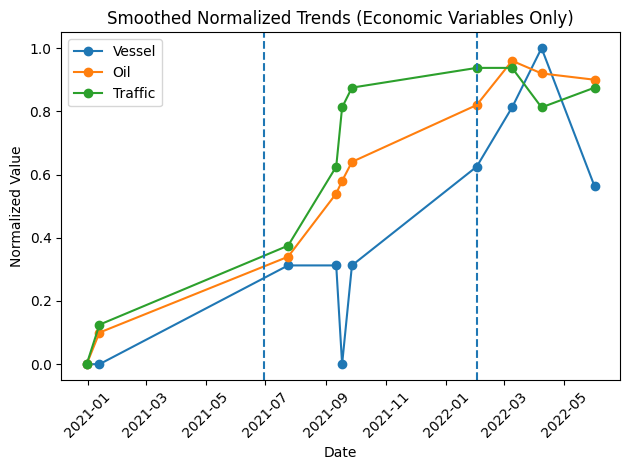

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Object detected - Sheet1.csv')

# Clean date
df['Date_clean'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date_clean')

# Select only economic variables
df = df[['Date_clean',
         'Vessel detected in the open-water proximity to the port',
         'Brent_Oil_Price_USD',
         'Barcelona_Traffic_MTonnes']].dropna()

df.columns = ['date','vessel','oil','traffic']

# Normalize
df_norm = (df[['vessel','oil','traffic']] - df[['vessel','oil','traffic']].min()) / \
          (df[['vessel','oil','traffic']].max() - df[['vessel','oil','traffic']].min())

# Smooth using rolling mean
df_smooth = df_norm.rolling(window=2, min_periods=1).mean()

# Plot
plt.figure()
plt.plot(df['date'], df_smooth['vessel'], marker='o', label='Vessel')
plt.plot(df['date'], df_smooth['oil'], marker='o', label='Oil')
plt.plot(df['date'], df_smooth['traffic'], marker='o', label='Traffic')

# Phase markers
plt.axvline(pd.Timestamp('2021-06-30'), linestyle='--')
plt.axvline(pd.Timestamp('2022-02-01'), linestyle='--')

plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.title("Smoothed Normalized Trends (Economic Variables Only)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()